In [1]:
from build_galaxy_db import *
import pandas as pd
from config import config, get_config
import illustris_python as il
from utils import *
from Grid_halo import *
from matplotlib import pyplot as plt
from plotting import *
from tng_cosmo import TNGcosmo
import h5py
from gaussian_outflow_selection import *
from plot_progenitor_evolution import *
from write_halo_db import *
from analyse_outflow_properties import *
from add_sfr_radius import *
from process_gas import *
from convergence_analyser import ConvergenceAnalyser
from write_halo_db import GalaxyWriter
from analyse_outflow_properties import OutflowPropUpdater
from galaxy_shell_outflows import GalaxyShells
from los_projection import GalaxyProjections
from add_metallicities import *
from find_progenitors import *
from tng_backend import TNGBackend
from serra_backend import SerraBackend
from test_selection import *

In [ ]:
# --- Backend setup ---
tng_backend = TNGBackend(config=config)
serra_backend = SerraBackend(base_path="/ptmp/mpa/ivkos/outflows")

In [2]:
from astropy.cosmology import Planck18 as cosmo

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
jades = get_jades_data()

In [5]:
m_star = np.concatenate(jades["M_star_log_Oiii"], ["M_star_log_Ha"])

/freya/u/ivkos/outflows/test_selection.py:158: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.text(0.98, 0.65, 'actual outflows', transform=ax2.transAxes,


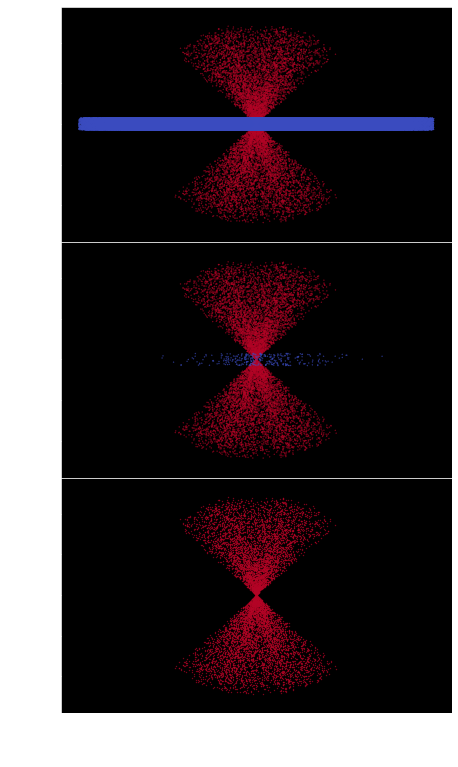

In [ ]:
plot_outflow_comparison_test(for_slides=True)

In [10]:
serra_path = "/ptmp/mpa/ivkos/outflows/serra_out_W80_sfr.hdf5"
# path = "/ptmp/mpa/ivkos/outflows/in_aperture_final.hdf5"
path = "/ptmp/mpa/ivkos/outflows/in_aperture_wind.hdf5"

# path = "/ptmp/mpa/ivkos/outflows/random_projections.hdf5"
df = pd.read_hdf(path)
df_serra = pd.read_hdf(serra_path)
df['M_out_log'] = np.log10(df['M_out']*1e10/cosmo.h)
df['M_out_aperture_log'] = np.log10(df['M_out_0.6']*1e10/cosmo.h)
df['M_out_aperture_log_03'] = np.log10(df['M_out_aperture']*1e10/cosmo.h)
df['M_star_log'] = np.log10(df['Galaxy_M_star']*1e10/cosmo.h)
df['SFR_hist10_log'] = np.log10(df['SFR_hist10'])
df['Z_ratio'] = df['outflow_Z_aperture']/df['remain_Z_aperture']
df_serra['M_out_aperture_log'] = np.log10(df_serra['M_out_0.6'])
df_serra['SFR_hist10_log'] = np.log10(df_serra['sfr_10'])
df_serra['Z_ratio'] = df_serra['outflow_Z_aperture']/df_serra['remain_Z_aperture']

/u/ivkos/conda-envs/outflows/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/ivkos/conda-envs/outflows/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/ivkos/conda-envs/outflows/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/ivkos/conda-envs/outflows/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
am_path = "/ptmp/mpa/ivkos/outflows/amaryllis.hdf5"
df_am = pd.read_hdf(am_path)
df_am['Halo_id'] = df_am['idx']
compute_r_sfr_serra(df_am, serra_backend)

1.240216285794442
Processed 0.00% of galaxies


1.0335135714953685
2.067027142990737
[2.893838 2.893838 2.893838]


/freya/u/ivkos/outflows/Grid_halo.py:141: RuntimeWarning: invalid value encountered in divide
  grids["Masses"] != 0, grids[quant] / grids["Masses"], 0
/freya/u/ivkos/outflows/Grid_halo.py:176: RuntimeWarning: invalid value encountered in divide
  np.true_divide(data.sum(dir), masses.sum(dir)),


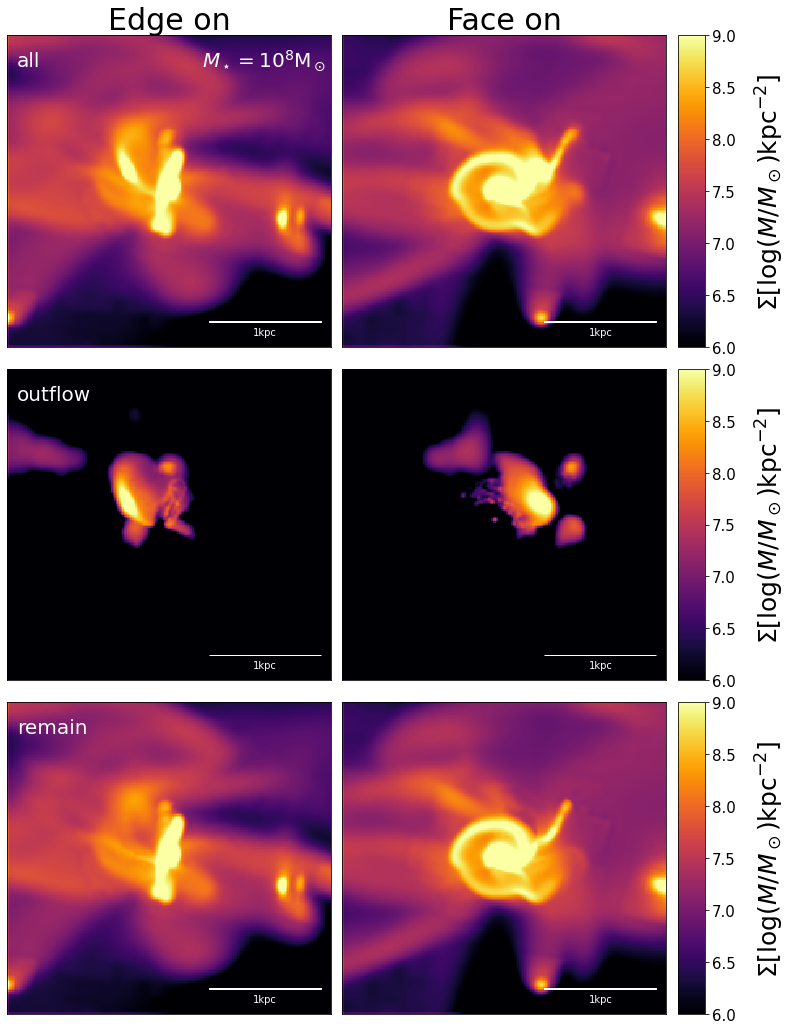

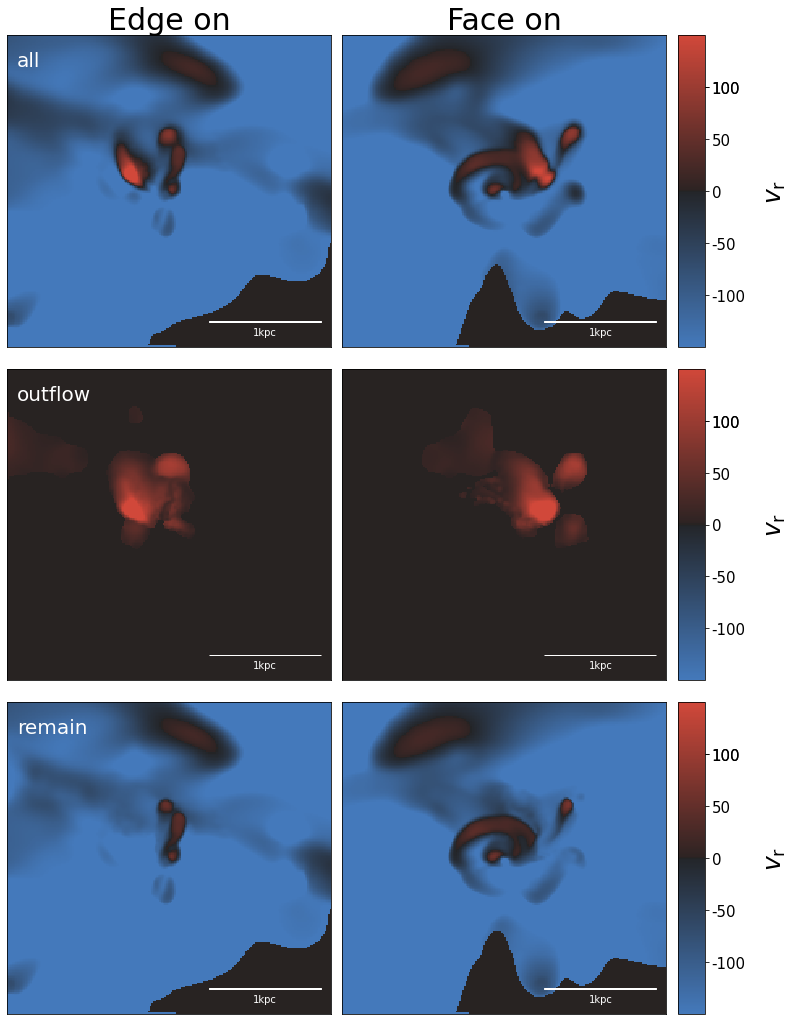

In [7]:
plot_prop_maps_grouped(
        halo_id=4276,
        df=df_am,
        snap=24,
        props=["Masses","Flow_Velocities"],
        backend=serra_backend,
        grid_size=100,
        method="GMM",
        group_props=None,
        dirs=[1, 2],
        sizebar_length=1,
        projection_angle_theta=None,
        projection_angle_phi=0,
        for_slides=False,
    )

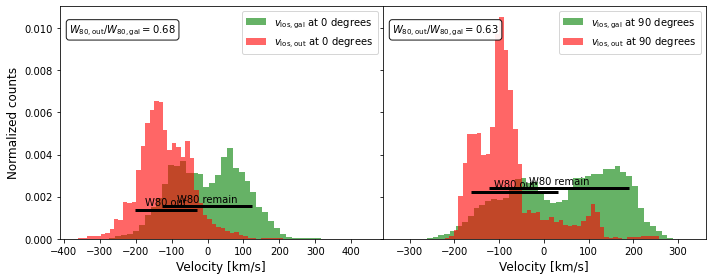

In [12]:
w80_histogram_single(df_am, halo_id=4276, snap=24, backend=serra_backend)

In [14]:
gal = Galaxy(df=df_am, halo_id=4276, snap=24, aperture_size=0.25, backend=serra_backend)

1.0335135714953685


In [18]:
out_gas = gal.get_in_aperture(gal.out_gas)

In [26]:
out_gas = gal.get_in_aperture(gal.out_gas)
remain_gas = gal.get_in_aperture(gal.remain_gas)
all_gas = gal.get_in_aperture(gal.gas)


In [32]:
with h5py.File("amaryllis_data.hdf5", "w") as f:
    
    grp = f.create_group("out_gas")
    for k, v in out_gas.items():
        grp.create_dataset(k, data=v)

    grp = f.create_group("remain_gas")
    for k, v in remain_gas.items():
        grp.create_dataset(k, data=v)

    grp = f.create_group("all_gas")
    for k, v in all_gas.items():
        grp.create_dataset(k, data=v)

In [30]:
print(all_gas['mass'].sum())
print(remain_gas['mass'].sum()+out_gas['mass'].sum())
print(out_gas['mass'].sum())

611726202.0428206
611726202.0428206
99003320.057335


In [33]:
out_gas['Physical_Relative_Distances'].max()

1.0331050097678718

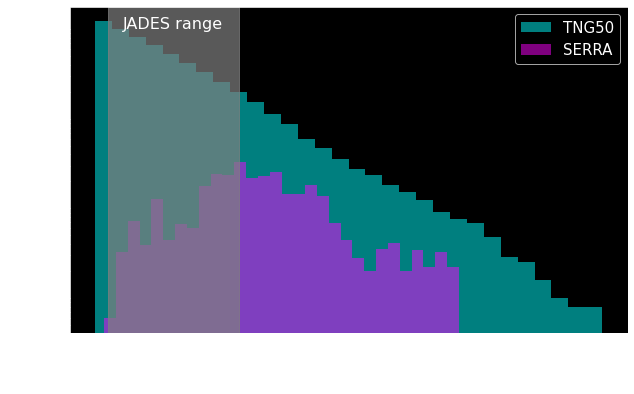

In [21]:
plot_mass_histograms(df_tng=df, df_serra=df_serra, bins=30, for_slides=True)

In [11]:
for key in df_serra.keys():
    print(key)

snap
z
Galaxy_M_star
idx
Galaxy_pos_x
Galaxy_pos_y
Galaxy_pos_z
Galaxy_vel_x
Galaxy_vel_y
Galaxy_vel_z
SubhaloVelDisp
M_star_log
r_SFR
Halo_id
M_dot_0.6
M_dot
outflow_Z
remain_Z
outflow_Z_aperture
remain_Z_aperture
M_out_0.6
v_mass_50
v_mass_80
v_mass_90
W80_outflow_0_0
delta_v_outflow_0_0
W80_galaxy_0_0
delta_v_galaxy_0_0
W80_outflow_0_30
delta_v_outflow_0_30
W80_galaxy_0_30
delta_v_galaxy_0_30
W80_outflow_0_60
delta_v_outflow_0_60
W80_galaxy_0_60
delta_v_galaxy_0_60
W80_outflow_0_90
delta_v_outflow_0_90
W80_galaxy_0_90
delta_v_galaxy_0_90
StarFormationRate
sfr_0
sfr_10
sfr_50
sfr_100
M_out_aperture_log
SFR_hist10_log
Z_ratio


(0.0, 15.0)

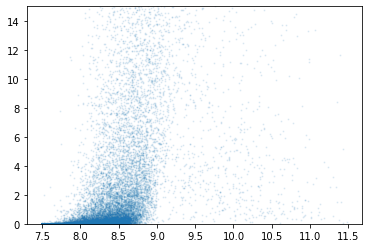

In [13]:
plt.scatter(df.M_star_log, df.ratio, s=1, alpha=0.1)
plt.ylim(0,15)

In [12]:
df['ratio'] =

In [21]:
df[df.M_star_log<9].ratio

13678    0.020238
13681    0.028777
13683    0.023835
13687    0.015956
13688    0.068119
           ...   
22704         inf
22714         inf
22764         inf
23008         inf
23358         inf
Name: ratio, Length: 3798, dtype: float64

In [25]:
df[df.snap==25].sort_values('M_star_log').tail(20)[['BH_growth', 'M_star_log', 'Halo_id', 'idx', 'snap']]

,BH_growth,M_star_log,Halo_id,idx,snap
132047,0.022888,10.732706,8,18517,25
132068,0.023288,10.766831,29,41086,25
132059,0.025920,10.777961,20,33084,25
132054,0.022739,10.791327,15,27873,25
132070,0.039660,10.797449,31,42584,25
132043,0.022592,10.818619,4,12907,25
132048,0.012451,10.839201,9,20563,25
132066,0.035634,10.882306,27,39760,25
132046,0.012332,10.935524,7,17197,25
132060,0.032853,10.978597,21,34088,25


In [78]:
galaxies = get_progenitor_histories(df, idces=[10843])

KeyboardInterrupt: 

In [29]:
path = "/ptmp/mpa/ivkos/outflows/massive_galaxy.pickle"
with open(path, "wb") as f:
    pickle.dump(galaxies, f)

In [86]:
path = "/ptmp/mpa/ivkos/outflows/history_2.pickle"
# Load galaxy from pickle file
with open(path, "rb") as f:
    galaxy = pickle.load(f)

In [89]:
galaxy[124586].keys()

dict_keys(['Halo_pos_x', 'Halo_pos_y', 'Halo_pos_z', 'Halo_M', 'Halo_M_gas', 'Halo_M_star', 'R_vir', 'Halo_id', 'Galaxy_pos_x', 'Galaxy_pos_y', 'Galaxy_pos_z', 'Galaxy_M_gas', 'Galaxy_M_star', 'Galaxy_M_wind', 'Galaxy_SFR', 'Galaxy_GHMR', 'Galaxy_SHMR', 'Galaxy_vel_x', 'Galaxy_vel_y', 'Galaxy_vel_z', 'BH_growth', 'Galaxy_star_fraction', 'Galaxy_gas_fraction', 'snap', 'idx', 'r_SFR', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasMetallicitySfr', 'SubhaloVelDisp', 'SubhaloVmax', 'M_star_log', 'z', 'M_out', 'M_dot', 'v_lum', 'v_mass', 'M_out_aperture', 'M_dot_aperture', 'v_lum_aperture', 'v_mass_aperture', 'outflow_Z', 'remain_Z', 'outflow_Z_aperture', 'remain_Z_aperture', 'M_out_cold', 'M_dot_cold', 'v_lum_cold', 'v_mass_cold', 'W80_outflow_0_0', 'delta_v_outflow_0_0', 'W80_galaxy_0_0', 'delta_v_galaxy_0_0', 'W80_outflow_0_30', 'delta_v_outflow_0_30', 'W80_galaxy_0_30', 'delta_v_galaxy_0_30', 'W80_outflow_0_60', 'delta_v_outflow_0_60', 'W80_galaxy_0_60', 'delta_v_ga

In [82]:
for key in galaxy.keys():
    print(galaxy[key][''][0])


-0.9014384271032885
0.603330711544773
0.25859215733620644
-0.23217573520080315
-0.5764388038463366
-0.4936854807943387
-0.04024894297142012
0.1782006521249091
0.21049622529380407
0.1851713480593702
-0.36761241242971643
-0.014975352158176136
0.2680057460523706
0.11112453137993761
-1.2616401621693552
0.1422817099748741
0.21862640446129866
0.30691673595943847
-0.23479263782007642
0.30034449243798456


In [59]:
!ls /ptmp/mpa/ivkos/outflows/*pickle

/ptmp/mpa/ivkos/outflows/history_2.pickle
/ptmp/mpa/ivkos/outflows/history.pickle
/ptmp/mpa/ivkos/outflows/massive_galaxy.pickle
/ptmp/mpa/ivkos/outflows/sfr_hist_99.pickle
/ptmp/mpa/ivkos/outflows/sfr_hist_full.pickle
/ptmp/mpa/ivkos/outflows/sfr_hist.pickle


In [ ]:
gaa

In [139]:
rel_galaxies = {}
for key in galaxy.keys():
    if np.sum(~np.isnan(galaxy[key]['M_out/M_star']))>12:
        if galaxy[key]['M_out/M_star'][11]>5.2:
            rel_galaxies[key] = galaxy[key]


In [140]:
rel_galaxies.keys()

dict_keys([125020, 147746, 149004, 153887])

In [141]:
del rel_galaxies[153887]

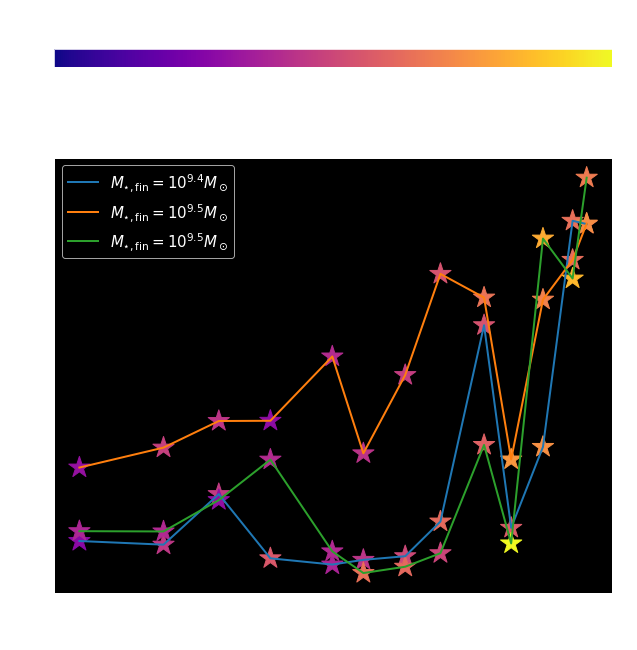

In [142]:
plot_galaxy_evolution(
    rel_galaxies, prop_x='lookback', prop_y='M_out/M_star', color_prop='sSFR_log', for_slides=True, title=None
)

In [6]:
df['W80_ratio_random'] = df["W80_sample_outflow_aperture"]/df["W80_sample_galaxy_aperture"]

In [10]:
df_test = df['W80_ratio_random'].dropna()

In [14]:
(df_test>1.2).sum()/len(df_test)    

0.6648242575220894

In [13]:
df.keys()

Index(['Halo_pos_x', 'Halo_pos_y', 'Halo_pos_z', 'Halo_M', 'Halo_M_gas',
       'Halo_M_star', 'R_vir', 'Halo_id', 'Galaxy_pos_x', 'Galaxy_pos_y',
       ...
       'v_mass_80', 'v_mass_90', 'M_out_0.6', 'M_dot_0.6', 'SFR_hist10',
       'SFR_hist50', 'SFR_hist100', 'M_out_aperture_log_03', 'SFR_hist10_log',
       'Z_ratio'],
      dtype='object', length=130)

In [5]:
df_serra.keys()

Index(['snap', 'z', 'Galaxy_M_star', 'idx', 'Galaxy_pos_x', 'Galaxy_pos_y',
       'Galaxy_pos_z', 'Galaxy_vel_x', 'Galaxy_vel_y', 'Galaxy_vel_z',
       'SubhaloVelDisp', 'M_star_log', 'r_SFR', 'Halo_id', 'M_dot_0.6',
       'M_dot', 'outflow_Z', 'remain_Z', 'outflow_Z_aperture',
       'remain_Z_aperture', 'M_out_0.6', 'v_mass_50', 'v_mass_80', 'v_mass_90',
       'W80_outflow_0_0', 'delta_v_outflow_0_0', 'W80_galaxy_0_0',
       'delta_v_galaxy_0_0', 'W80_outflow_0_30', 'delta_v_outflow_0_30',
       'W80_galaxy_0_30', 'delta_v_galaxy_0_30', 'W80_outflow_0_60',
       'delta_v_outflow_0_60', 'W80_galaxy_0_60', 'delta_v_galaxy_0_60',
       'W80_outflow_0_90', 'delta_v_outflow_0_90', 'W80_galaxy_0_90',
       'delta_v_galaxy_0_90', 'StarFormationRate', 'sfr_0', 'sfr_10', 'sfr_50',
       'sfr_100', 'M_out_aperture_log', 'SFR_hist10_log', 'Z_ratio'],
      dtype='object')

both contours


/freya/u/ivkos/outflows/plotting.py:1206: RuntimeWarning: divide by zero encountered in log10
  hist = np.log10(hist)


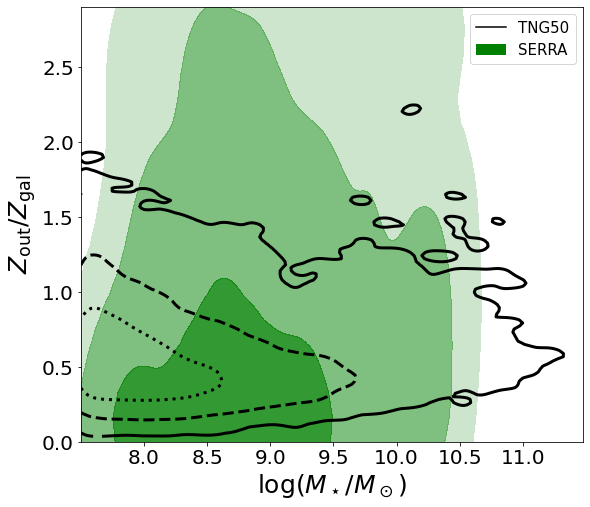

In [12]:
prop_prop_histogram_overlayed(
    df,
    df_serra, 
    prop_x="M_star_log",
    prop_y="Z_ratio",
    color_prop="M_out_aperture_log",
    statistic="count",
    em_weighted=False,
    log_x=False,
    log_y=False,
    bins_x=12,
    bins_y=12,
    color_log=False,
    contour=True,
    quantile=None,
    for_slides=False,
    title=None,
    with_histogram=False,
    both_contours=True,
    with_labels=False,
)

In [14]:
df['M_out_aperture']

13661     0.010784
13662     0.023732
13663     0.006712
13664     0.000248
13665     0.000232
            ...   
145861    0.000796
146150    0.000972
146345         NaN
146472    0.000420
147076         NaN
Name: M_out_aperture, Length: 60876, dtype: float64

In [34]:
df['wind_mass']

13661     1.345809e+10
13662     8.995759e+09
13663     1.380886e+09
13664     1.337630e+09
13665     1.647331e+09
              ...     
145861    0.000000e+00
146150    0.000000e+00
146345    0.000000e+00
146472    0.000000e+00
147076    0.000000e+00
Name: wind_mass, Length: 60876, dtype: float64

In [6]:
df['M_out_and_wind_log'] = np.log10(10**df['M_out_aperture_log'] + df['wind_mass'])

In [7]:
df['M_wind_log'] = np.log10(df['wind_mass'])


/u/ivkos/conda-envs/outflows/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
import numpy as np

b = np.array([False, False, True, False, False, False, True, False])
n = len(b)

idx = np.arange(n)

# distance to nearest True on the left
left = np.where(b, idx, -np.inf)
print(idx)
left = np.maximum.accumulate(left)
print(left)
dist_left = idx - left

print(dist_left)

[0 1 2 3 4 5 6 7]
[-inf -inf   2.   2.   2.   2.   6.   6.]
[inf inf  0.  1.  2.  3.  0.  1.]


/freya/u/ivkos/outflows/plotting.py:886: RuntimeWarning: divide by zero encountered in log10
  hist = np.log10(hist)


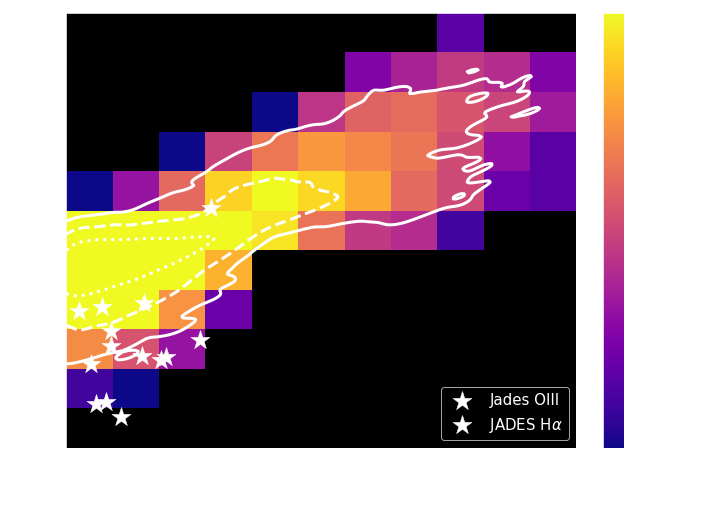

In [26]:
prop_prop_histogram(
    df,
    prop_x="M_star_log",
    prop_y='M_out_and_wind_log',
    color_prop='M_out_aperture_log',
    statistic="count",
    em_weighted=False,
    log_x=False,
    log_y=False,
    bins_x=12,
    bins_y=12,
    color_log=False,
    contour=True,
    quantile=None,
    for_slides=True,
    title=None,
    with_contours=True,
    with_fits=True,
)

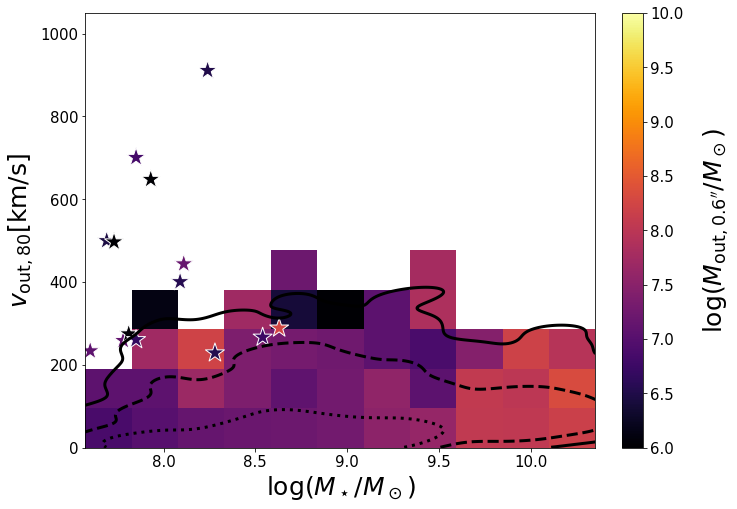

In [8]:
prop_prop_histogram(
    df_serra,
    prop_x="M_star_log",
    prop_y='v_mass_80',
    color_prop='M_out_aperture_log',
    statistic="median",
    em_weighted=False,
    log_x=False,
    log_y=False,
    bins_x=20,
    bins_y=20,
    color_log=False,
    contour=True,
    quantile=None,
    for_slides=False,
    title=None,
    with_contours=True,
)

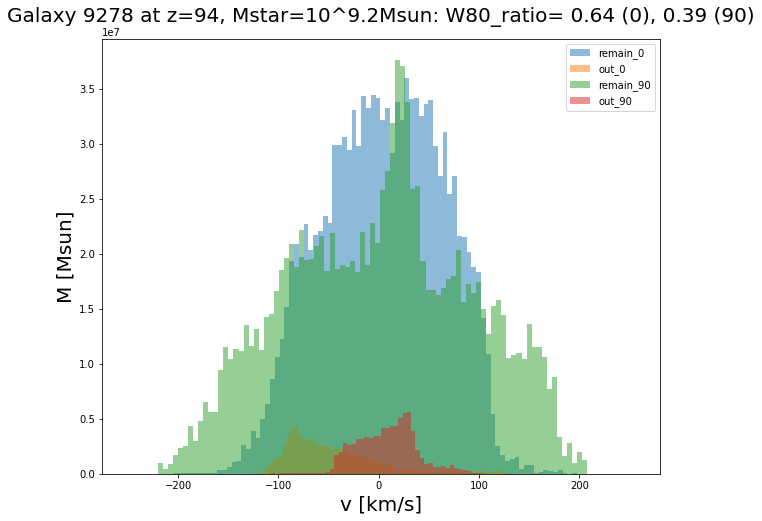

In [6]:
id = 9278
snap = 94
plot_distributions(df, id, snap, backend=serra_backend)

In [13]:
np.log10(5e10)

10.698970004336019

In [ ]:
df[(df.M_star_log>10.4)&(df.z>3.2)&(df.z<3.4)&(df.M_star_log<12)]

In [ ]:
df[(df.z>3.0)&(df.z<3.5)&(df.snap==24)&(df.M_star_log<8.001)&(df.M_star_log>7.999)][['M_star_log', 'snap', 'z', 'Halo_id', "BH_growth"]]


In [57]:
snap = 62
id = 3522

In [58]:
df_serra[(df_serra.snap==snap) & (df_serra.Halo_id==id)][['M_star_log', 'snap', 'z']]

,M_star_log,snap,z
1348,8.030144,62,5.041576


In [53]:
10**10.311

20464446367.24674

/freya/u/ivkos/outflows/Grid_halo.py:144: RuntimeWarning: invalid value encountered in divide
  grids["Masses"] != 0, grids[quant] / grids["Masses"], 0
/freya/u/ivkos/outflows/Grid_halo.py:179: RuntimeWarning: invalid value encountered in divide
  np.true_divide(data.sum(dir), masses.sum(dir)),


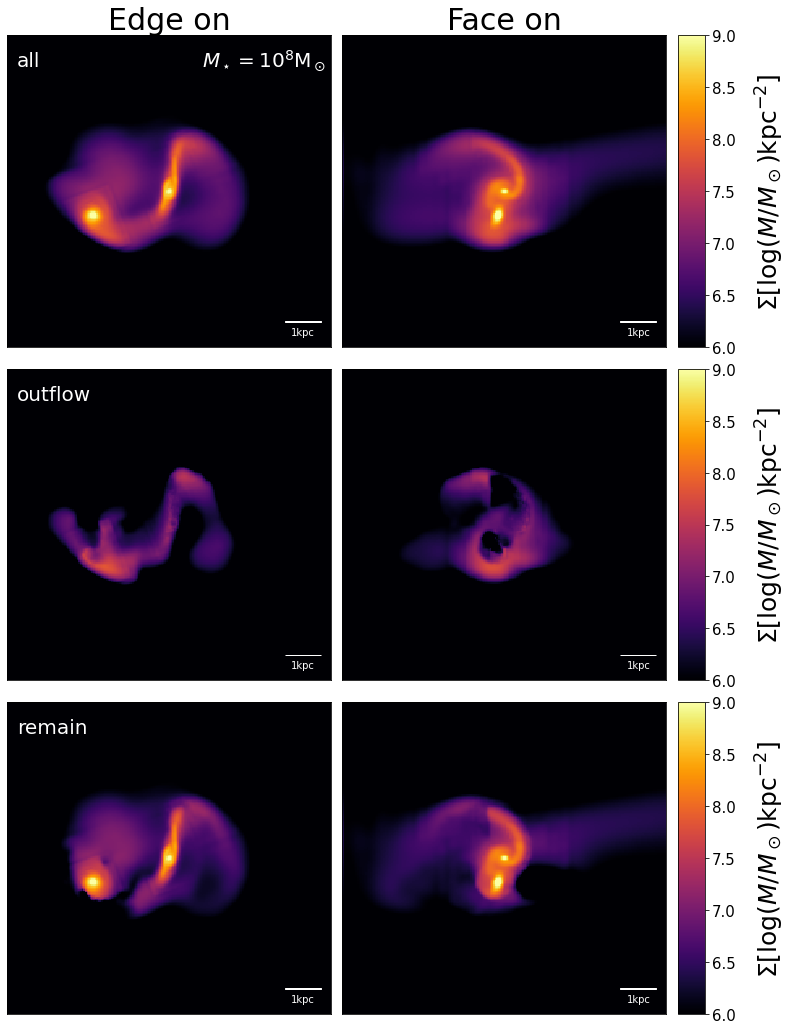

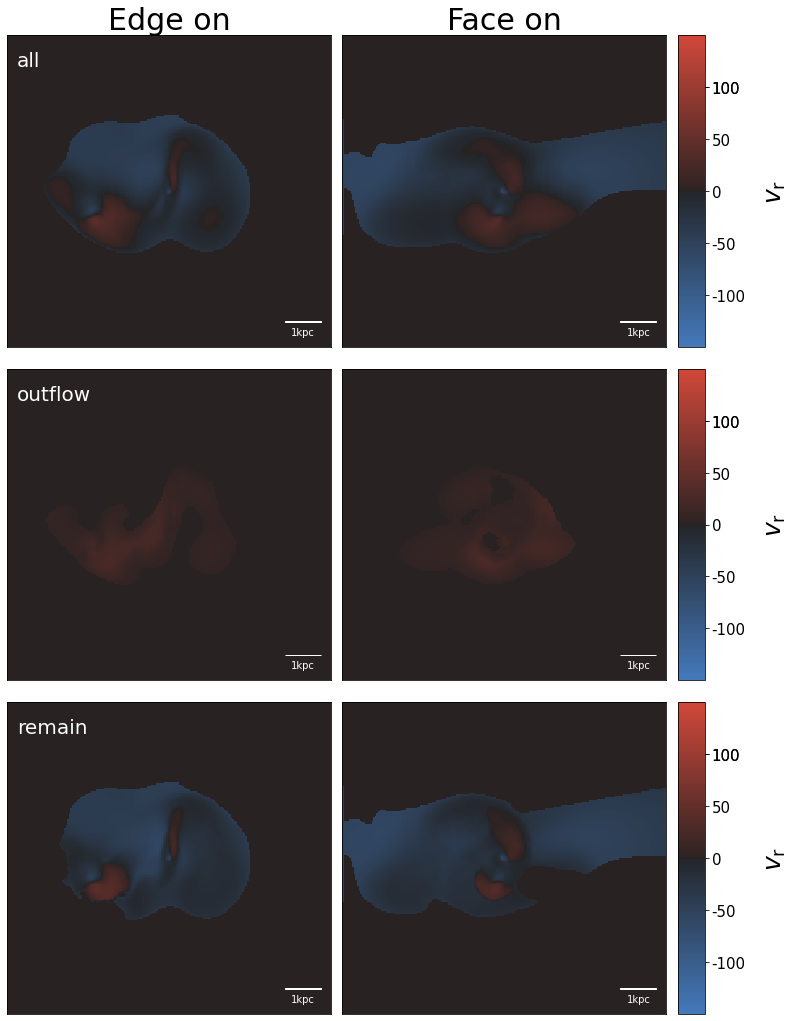

In [60]:
plot_prop_maps_grouped(
        halo_id=id,
        df=df_serra,
        snap=snap,
        props=["Masses","Flow_Velocities"],
        backend=serra_backend,
        grid_size=100,
        method="GMM",
        group_props=None,
        dirs=[1, 2],
        sizebar_length=1,
        projection_angle_theta=None,
        projection_angle_phi=0,
        for_slides=False,
    )

In [8]:
df_test = df[['snap', 'z', 'Galaxy_M_star', 'idx', 'Galaxy_pos_x', 'Galaxy_pos_y',
       'Galaxy_pos_z', 'Galaxy_vel_x', 'Galaxy_vel_y', 'Galaxy_vel_z',
       'SubhaloVelDisp', 'M_star_log', 'r_SFR', 'Halo_id']]

In [10]:
path_new = "/ptmp/mpa/ivkos/outflows/serra_base.hdf5"
df_test.to_hdf(path, key='base', mode='a')

In [ ]:
sample = df[['Halo_id', 'snap', 'M_out_0.6_log', 'M_star_log']].sample(30)

In [41]:
for _, element in sample.iterrows():
    gal = Galaxy(df=df, halo_id=int(element.Halo_id),
                 snap=int(element.snap),
                 aperture_size=0.6,
                 backend=tng_backend)
    gal.stars

/freya/u/ivkos/outflows/process_gas.py:184: RuntimeWarning: divide by zero encountered in log10
  self._wind = map_to_new_dict(stars_and_wind, wind_test)


Wind mass: -inf
Wind mass: 8.545621871948242
Wind mass: -inf
Wind mass: -inf
Wind mass: 7.426425457000732
Wind mass: -inf
Wind mass: -inf
Wind mass: 6.832198143005371
Wind mass: -inf
Wind mass: -inf
Wind mass: -inf
Wind mass: -inf
Wind mass: -inf
Wind mass: 7.3487443923950195
Wind mass: -inf
Wind mass: -inf
Wind mass: 5.582860946655273
Wind mass: -inf
Wind mass: 6.696580410003662
Wind mass: -inf
Wind mass: -inf
Wind mass: 5.12391996383667
Wind mass: -inf
Wind mass: 7.052897930145264
Wind mass: 5.563503265380859
Wind mass: -inf
Wind mass: 7.2570881843566895
Wind mass: -inf
Wind mass: -inf
Wind mass: 4.814655303955078


In [11]:
a = df[(df.M_star_log>9.5)&(df.snap==25)&(df.M_star_log<9.6)][['Halo_id', 'snap', 'idx']]

In [54]:
snaps = list(a.snap)[30:100]
ids = list(a.idx)[30:100]

In [55]:
galaxies = get_progenitor_histories(df, ids, snaps)

In [33]:
for i in galaxies.keys():
    galaxies[i]['sOutflow_lin'] = 10**galaxies[i]['sOutflow']

In [14]:
import pickle
def save_dict_pickle(dic, filename):
    with open(filename, 'wb') as f:
        pickle.dump(dic, f)

In [15]:
filename = "/ptmp/mpa/ivkos/outflows/history_2.pickle"
save_dict_pickle(galaxies, filename)

In [23]:
filename = "/ptmp/mpa/ivkos/outflows/history_2.pickle"
with open(filename, 'rb') as f:
    galaxies = pickle.load(f)

In [41]:
df.loc[103664]['idx']

0.0

In [49]:
df.snap.unique()

array([13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25])

In [50]:
galaxies=get_progenitor_histories(df, [0], [25])

Working on galaxy 0


/freya/u/ivkos/outflows/find_progenitors.py:247: RuntimeWarning: invalid value encountered in log10
  galaxy_dict["M_dot_log"] = np.log10(galaxy_dict["M_dot_conv"] * 1e6)


In [30]:
df['M_star_log'].sort_values().tail(20)

66780     11.154049
90478     11.185706
78316     11.186218
132051    11.186727
90480     11.225993
90481     11.226355
78313     11.235632
103668    11.261031
117597    11.298096
103664    11.305846
90479     11.333715
132042    11.336356
117594    11.346588
103666    11.350794
132039    11.385653
103665    11.393096
117595    11.402290
132040    11.428248
117596    11.437943
132041    11.477658
Name: M_star_log, dtype: float64

In [52]:
galaxies

{0: {'Halo_pos_x': [22700.142578125,
   22748.375,
   22754.560546875,
   22759.939453125,
   22794.2578125,
   22816.9609375,
   22795.5546875,
   nan,
   22734.125,
   22725.37890625,
   22713.962890625,
   22692.38671875,
   22684.990234375,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan],
  'Halo_pos_y': [15320.595703125,
   15278.509765625,
   15255.2333984375,
   15249.0615234375,
   15204.1337890625,
   15197.3837890625,
   15254.8046875,
   nan,
   15306.580078125,
   15309.6298828125,
   15321.0009765625,
   15327.8203125,
   15325.5185546875,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan],
  'Halo_pos_z': [3461.779541015625,
   3522.224609375,
   3559.71728515625,
   3612.292724609375,
   3660.13818359375,
   3660.220947265625,
   3727.1484375,
   nan,
   3921.5107421875,
   3973.10693359375,
   4045.048583984375,
   4099.76806640625,
   4127.541015625,
   nan,
   nan,
   nan,
   

KeyError: 'M_out/M_star'

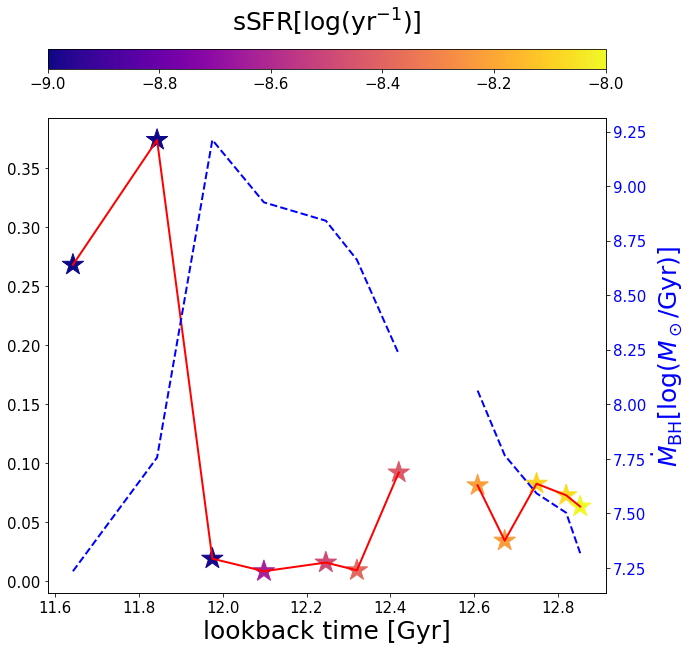

In [51]:
plot_galaxy_evolution(
    galaxies, prop_x='lookback', prop_y='M_out/M_star', color_prop='sSFR_log', prop_y2='BH_mdot_log', for_slides=False, title=None
)

In [11]:
galaxies.keys()

dict_keys([124586, 124737, 125020, 126167, 126559, 127640, 127762, 128869, 129276, 131550, 131882, 132118, 133011, 133254, 134929, 135092, 135251, 136325, 136507, 138045, 139292, 139459, 140828, 141397, 142598, 142797, 142910, 143065, 143359, 145345, 145873, 146955, 147100, 147237, 147746, 147901, 148258, 149004, 150797, 152196, 152827, 153267, 153887, 154002, 154844, 155329, 156440, 157171, 157809, 158968, 159531, 159638, 160365, 161439, 161743, 162386, 162778, 165040, 167411, 169188, 172709, 177757, 188542, 197540])

In [32]:
gal = Galaxy(df=df, halo_id=9593, snap=91, aperture_size=0.6, backend=serra_backend)

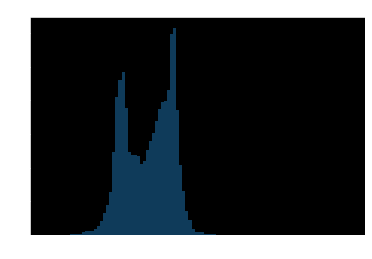

In [15]:
_ = plt.hist(gal.gas['v_los_x'], bins=100, weights=gal.gas['mass'], alpha=0.5, label='all')

In [37]:
gal = Galaxy(df=df, halo_id=10275, snap=79, aperture_size=0.6, backend=serra_backend)

/freya/u/ivkos/outflows/Grid_halo.py:144: RuntimeWarning: invalid value encountered in divide
  grids["Masses"] != 0, grids[quant] / grids["Masses"], 0
/freya/u/ivkos/outflows/Grid_halo.py:179: RuntimeWarning: invalid value encountered in divide
  np.true_divide(data.sum(dir), masses.sum(dir)),
/freya/u/ivkos/outflows/Grid_halo.py:179: RuntimeWarning: invalid value encountered in divide
  np.true_divide(data.sum(dir), masses.sum(dir)),


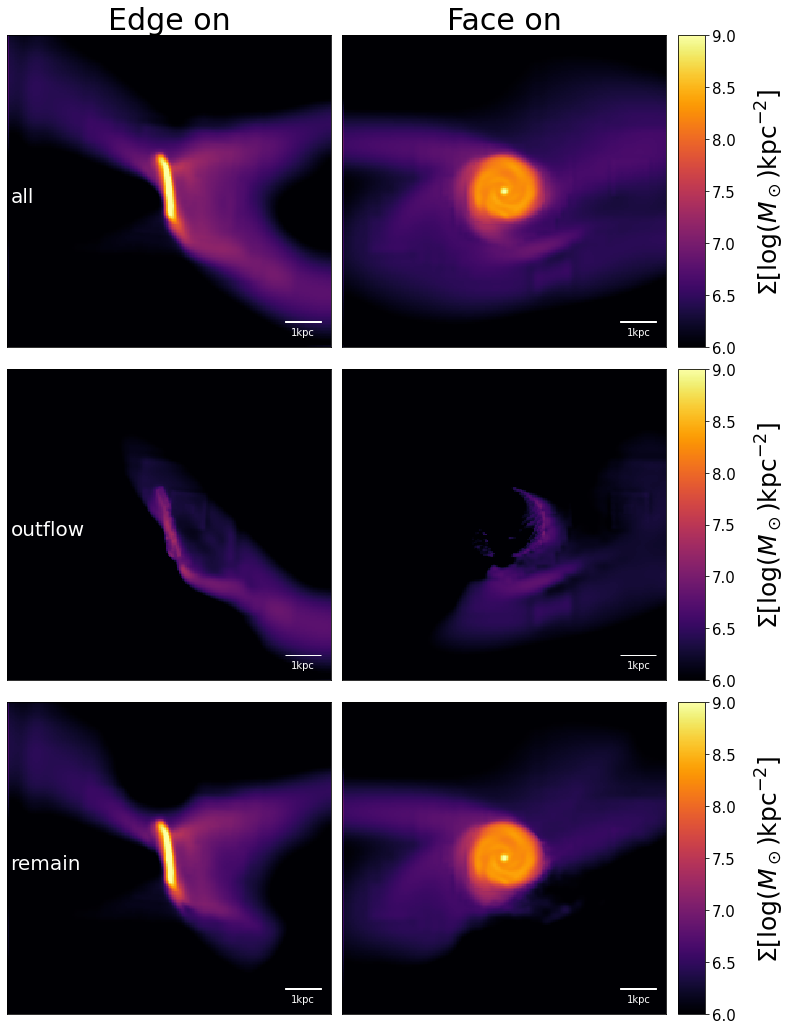

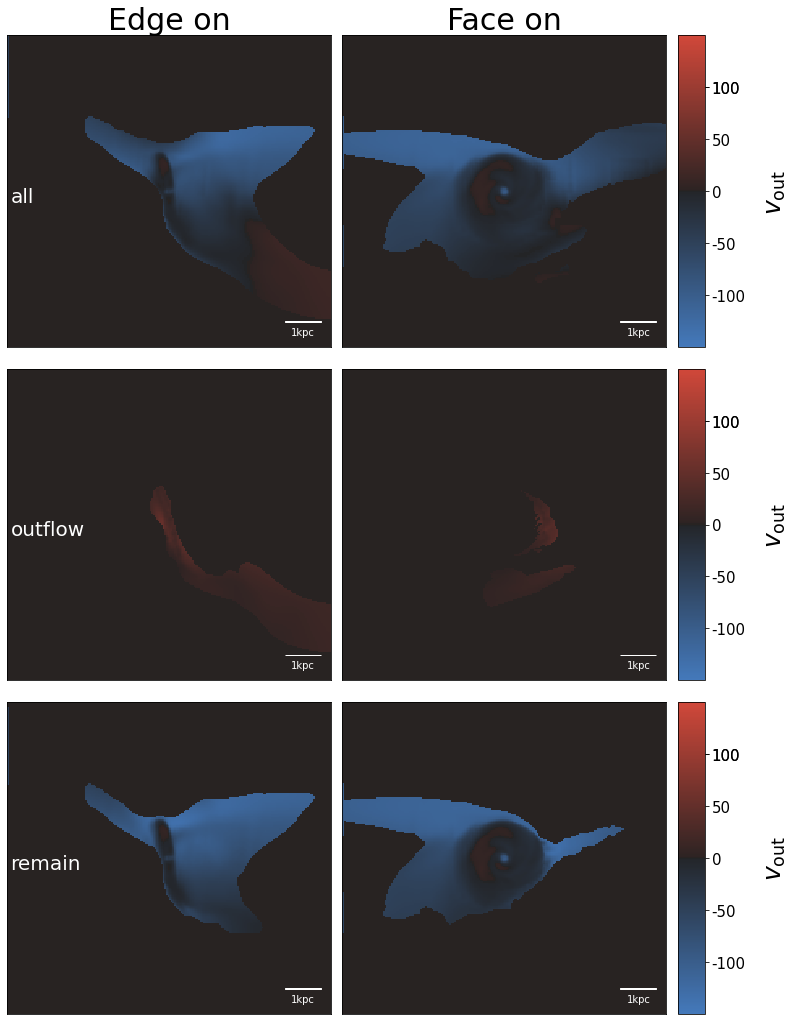

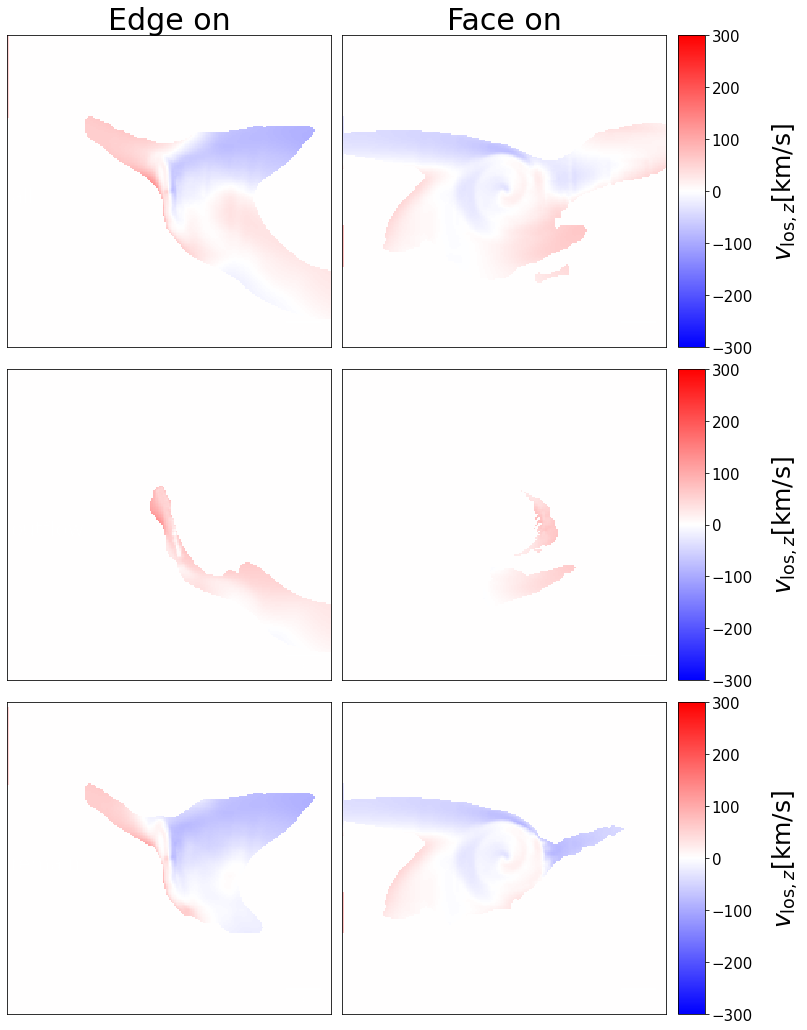

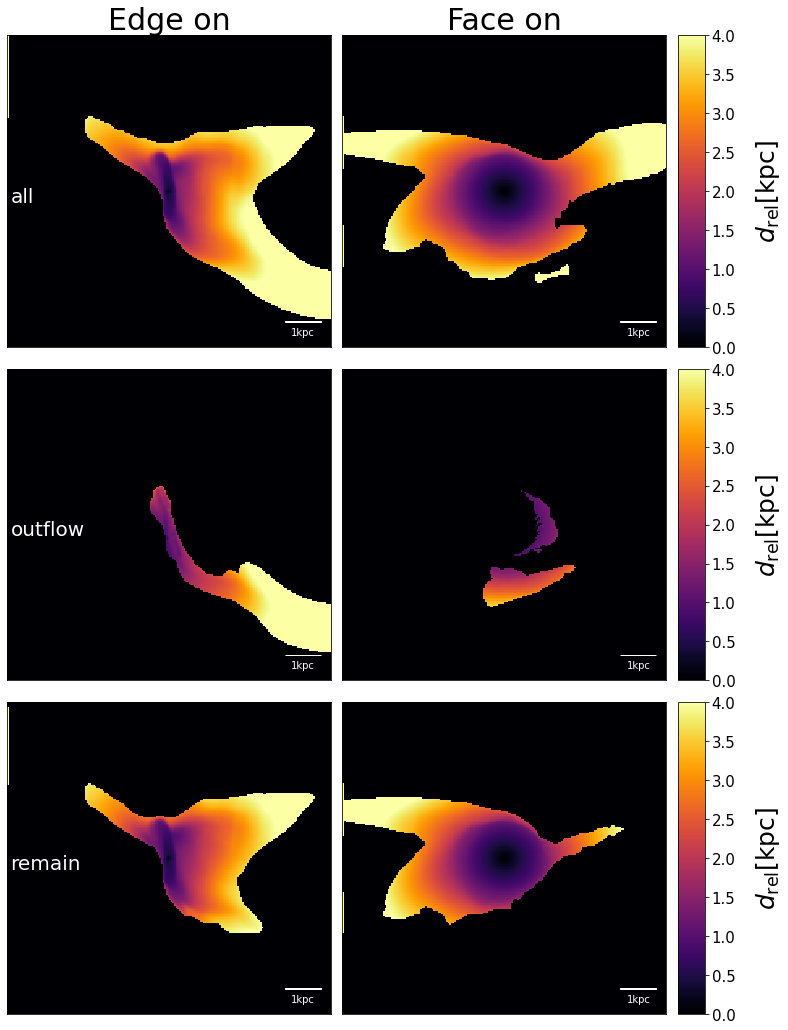

In [49]:
plot_prop_maps_grouped(
        halo_id=id,
        df=df,
        snap=snap,
        props=["Masses","Flow_Velocities", 'v_los_z', "Relative_Distances"],
        backend=serra_backend,
        grid_size=100,
        method="GMM",
        group_props=None,
        dirs=[1, 2],
        sizebar_length=1,
        projection_angle_theta=None,
        projection_angle_phi=0,
        for_slides=False,
    )

/freya/u/ivkos/outflows/Grid_halo.py:144: RuntimeWarning: invalid value encountered in divide
  grids["Masses"] != 0, grids[quant] / grids["Masses"], 0
/freya/u/ivkos/outflows/Grid_halo.py:179: RuntimeWarning: invalid value encountered in divide
  np.true_divide(data.sum(dir), masses.sum(dir)),


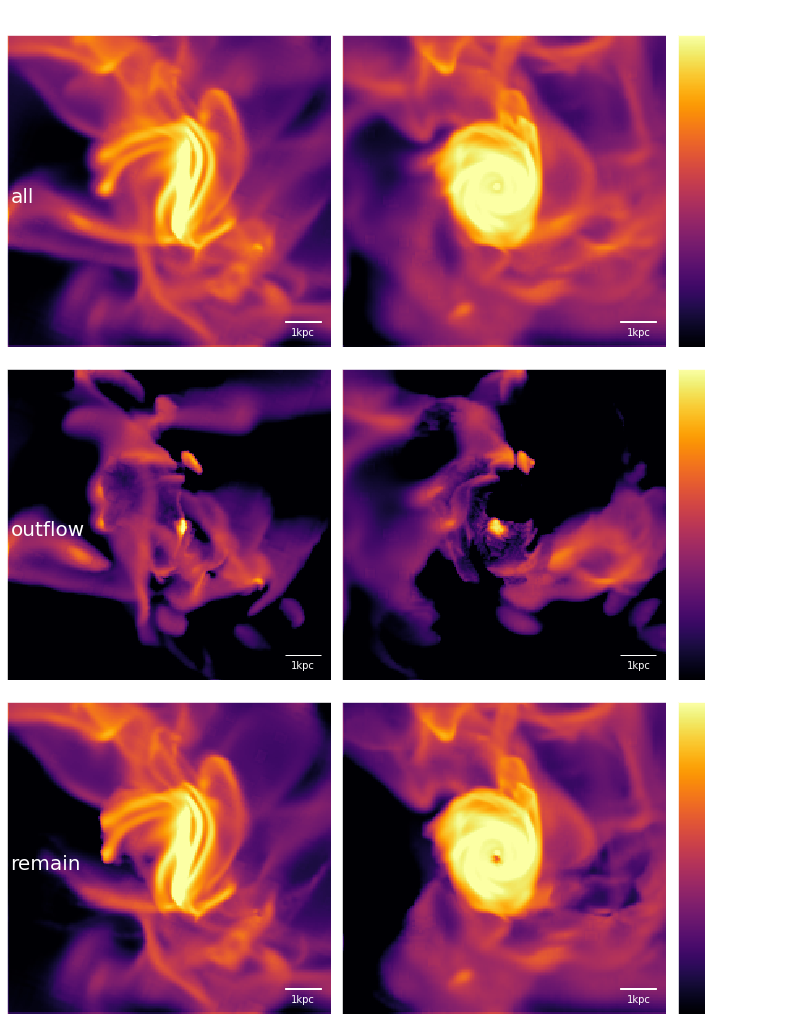

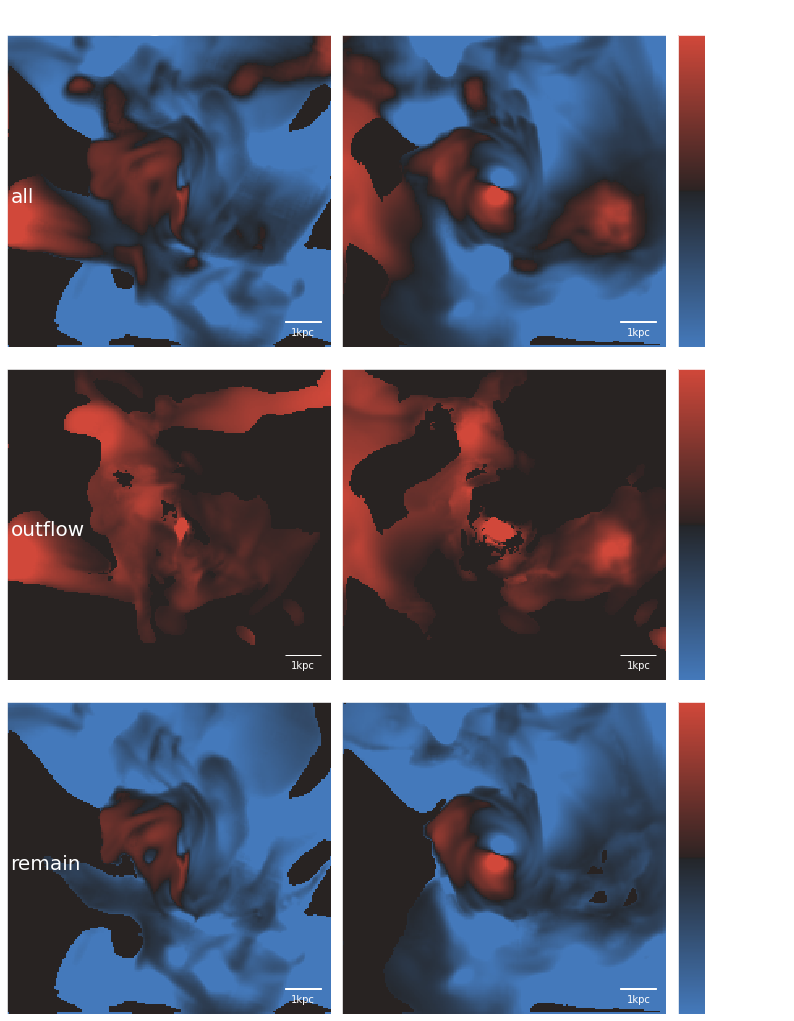

In [24]:
plot_prop_maps_grouped(
        halo_id=9523,
        df=df,
        snap=90,
        props=["Masses", "Flow_Velocities"],
        backend=serra_backend,
        grid_size=100,
        method="GMM",
        group_props=None,
        dirs=[1, 2],
        sizebar_length=1,
        projection_angle_theta=None,
        projection_angle_phi=0,
        for_slides=True,
    )

117525260.55699943


/freya/u/ivkos/outflows/Grid_halo.py:144: RuntimeWarning: invalid value encountered in divide
  grids["Masses"] != 0, grids[quant] / grids["Masses"], 0
/freya/u/ivkos/outflows/Grid_halo.py:179: RuntimeWarning: invalid value encountered in divide
  np.true_divide(data.sum(dir), masses.sum(dir)),
/freya/u/ivkos/outflows/Grid_halo.py:179: RuntimeWarning: invalid value encountered in divide
  np.true_divide(data.sum(dir), masses.sum(dir)),


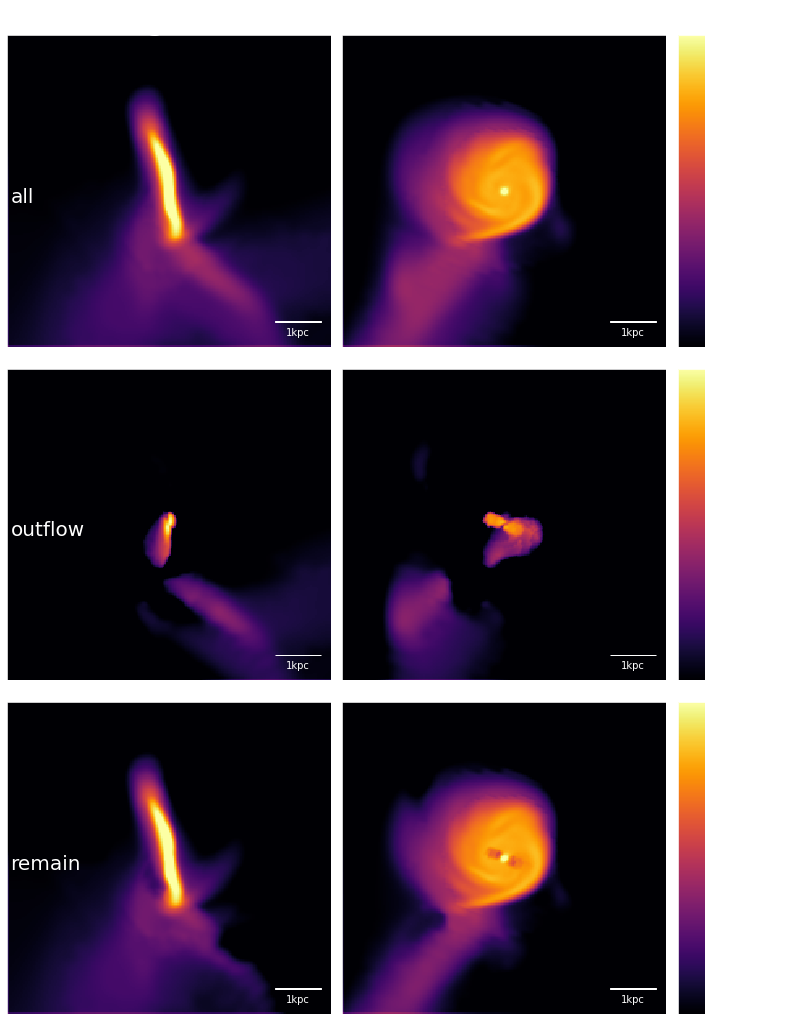

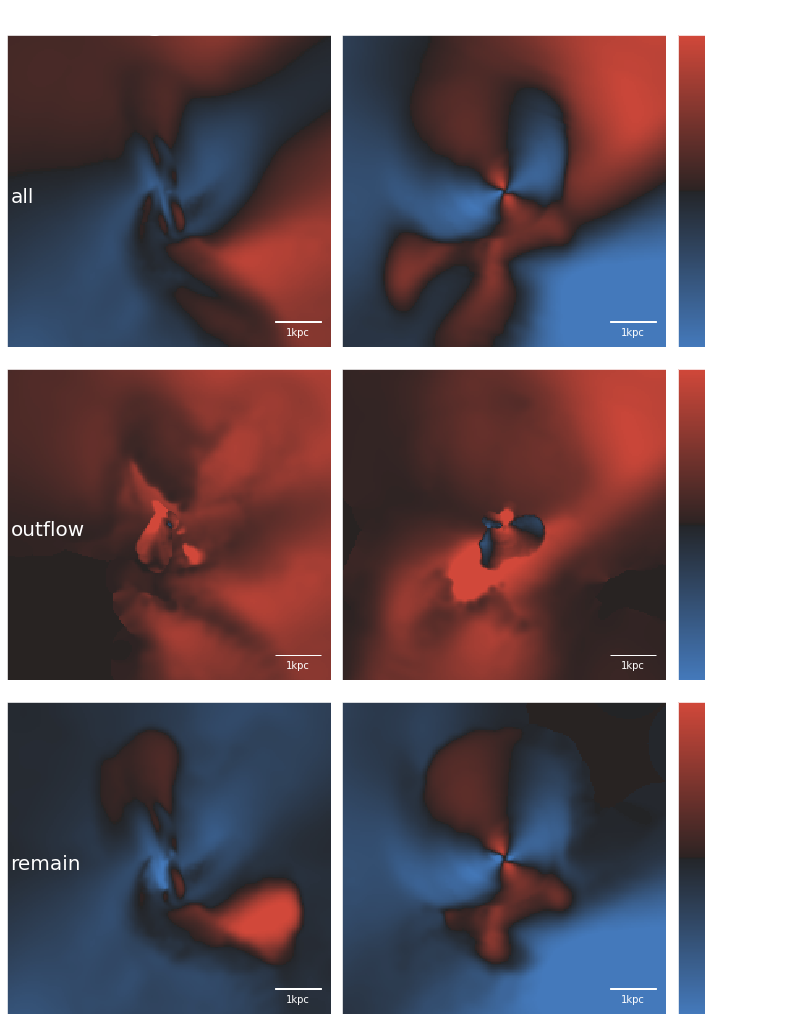

In [60]:
plot_prop_maps_grouped(
        halo_id=2218,
        df=df,
        snap=98,
        props=["Masses", "Flow_Velocities"],
        backend=serra_backend,
        grid_size=100,
        method="GMM",
        group_props=None,
        dirs=[1, 2],
        sizebar_length=1,
        projection_angle_theta=None,
        projection_angle_phi=0,
        for_slides=True,
    )

In [15]:
df['SFR_hist100_log'] = np.log10(df['SFR_hist100'])
df['sSFR_log'] = df['SFR_hist100_log']-df['M_star_log']
df['sOutflow'] = df['M_out_aperture_log'] - df['M_star_log']
df['eta'] = df['M_out']/df['SFR_hist10']

KeyError: 'SFR_hist100'

In [20]:
filter = df.M_star_log > 9.5

W80_outflow_0_0
W80_outflow_0_90


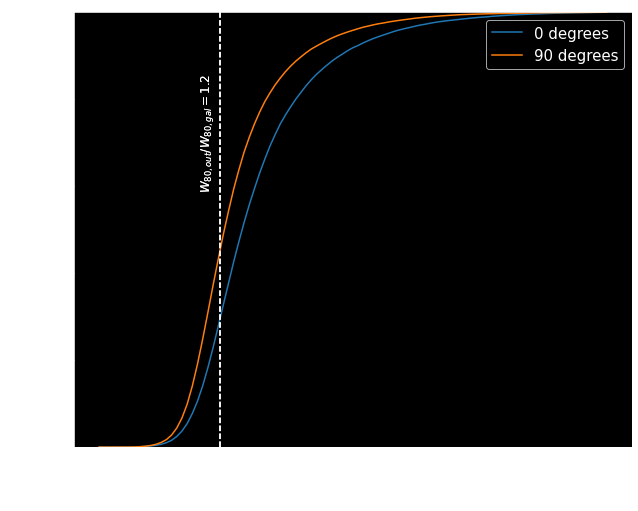

In [54]:
plot_W80_evolution(
    df,
    theta_angles=[0, 90],
    phi_angles=[0],
    bins=100,
    cumulative=True,
    for_slides=True,
    title=None,
    aperture=False,
)

In [74]:
filter = (df.M_star_log < 8)
title = r"$M_\star<10^8M_\odot$"

W80_outflow_0_0
W80_outflow_0_30
W80_outflow_0_60
W80_outflow_0_90


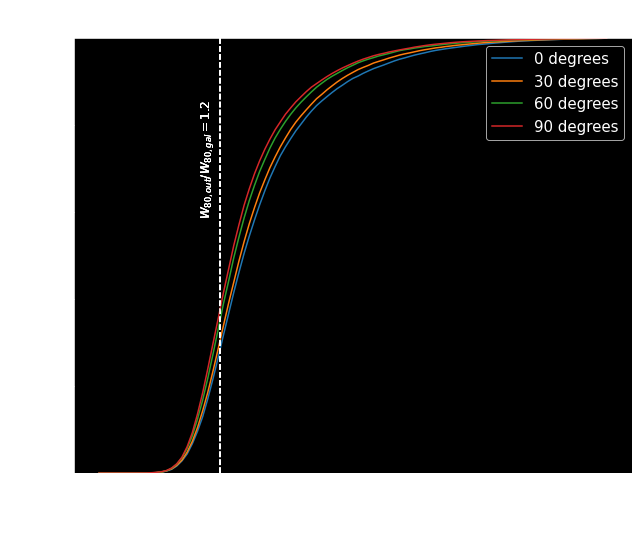

In [75]:
plot_W80_evolution(
    df[filter],
    theta_angles=[0, 30, 60, 90],
    phi_angles=[0],
    bins=100,
    cumulative=True,
    for_slides=True,
    title=title,
    aperture=False,
)

In [101]:
df['Z_ratio'] = df['outflow_Z_aperture']/df['remain_Z_aperture']

/u/ivkos/conda-envs/outflows/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [17]:
df.keys()

Index(['snap', 'z', 'Galaxy_M_star', 'idx', 'Galaxy_pos_x', 'Galaxy_pos_y',
       'Galaxy_pos_z', 'Galaxy_vel_x', 'Galaxy_vel_y', 'Galaxy_vel_z',
       'SubhaloVelDisp', 'M_star_log', 'r_SFR', 'Halo_id', 'M_dot_0.6',
       'M_dot', 'outflow_Z', 'remain_Z', 'outflow_Z_aperture',
       'remain_Z_aperture', 'M_out_0.6', 'v_mass_50', 'v_mass_80', 'v_mass_90',
       'W80_outflow_0_0', 'delta_v_outflow_0_0', 'W80_galaxy_0_0',
       'delta_v_galaxy_0_0', 'W80_outflow_0_30', 'delta_v_outflow_0_30',
       'W80_galaxy_0_30', 'delta_v_galaxy_0_30', 'W80_outflow_0_60',
       'delta_v_outflow_0_60', 'W80_galaxy_0_60', 'delta_v_galaxy_0_60',
       'W80_outflow_0_90', 'delta_v_outflow_0_90', 'W80_galaxy_0_90',
       'delta_v_galaxy_0_90', 'StarFormationRate', 'sfr_0', 'sfr_10', 'sfr_50',
       'sfr_100'],
      dtype='object')

/freya/u/ivkos/outflows/plotting.py:824: RuntimeWarning: divide by zero encountered in log10
  # col_norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)


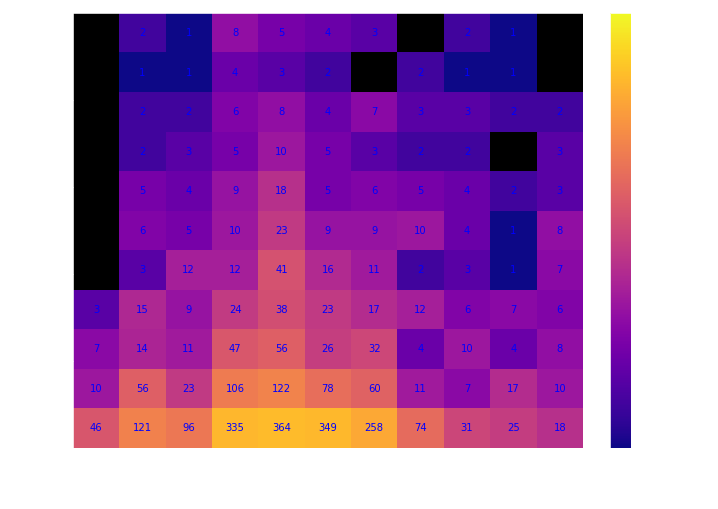

In [52]:
prop_prop_histogram(
    df,
    prop_x='M_star_log',
    prop_y='Z_ratio',
    color_prop="M_out_aperture_log",
    statistic="count",
    em_weighted=False,
    log_x=False,
    log_y=False,
    bins_x=12,
    bins_y=12,
    color_log=False,
    contour=True,
    for_slides=True,
)

/freya/u/ivkos/outflows/plotting.py:787: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=prop_x, inplace=True)
/freya/u/ivkos/outflows/plotting.py:788: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=prop_y, inplace=True)


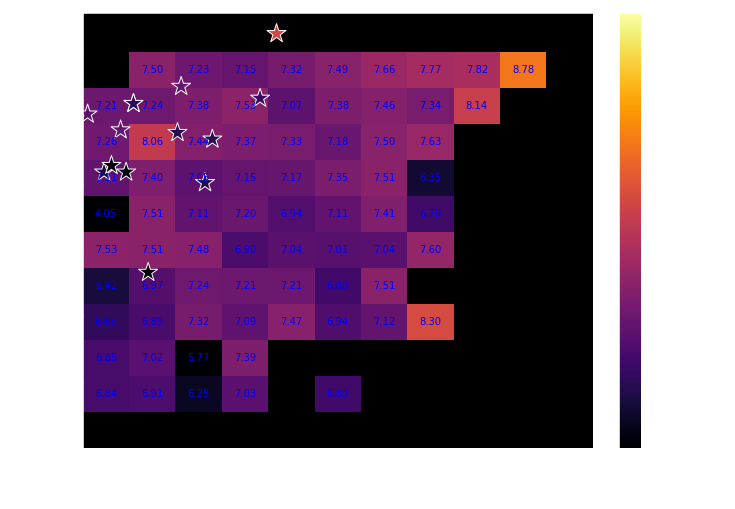

In [27]:
prop_prop_histogram(
    df[(df.M_out_aperture_log > -6)&(df.SFR_hist10_log > -6)],
    prop_x='M_star_log',
    prop_y='SFR_hist10_log',
    color_prop="M_out_aperture_log",
    statistic="median",
    em_weighted=False,
    log_x=False,
    log_y=False,
    bins_x=12,
    bins_y=12,
    color_log=False,
    contour=True,
    for_slides=True,
)

In [ ]:
for key in df.keys():
    print(key)

Halo_pos_x
Halo_pos_y
Halo_pos_z
Halo_M
Halo_M_gas
Halo_M_star
R_vir
Halo_id
Galaxy_pos_x
Galaxy_pos_y
Galaxy_pos_z
Galaxy_M_gas
Galaxy_M_star
Galaxy_M_wind
Galaxy_SFR
Galaxy_GHMR
Galaxy_SHMR
Galaxy_vel_x
Galaxy_vel_y
Galaxy_vel_z
BH_growth
Galaxy_star_fraction
Galaxy_gas_fraction
snap
idx
r_SFR
SubhaloGasMetallicity
SubhaloGasMetallicityHalfRad
SubhaloGasMetallicitySfr
SubhaloVelDisp
SubhaloVmax
M_star_log
z
M_out
M_dot
v_lum
v_mass
M_out_aperture
M_dot_aperture
v_lum_aperture
v_mass_aperture
outflow_Z
remain_Z
outflow_Z_aperture
remain_Z_aperture
M_out_cold
M_dot_cold
v_lum_cold
v_mass_cold
W80_outflow_0_0
delta_v_outflow_0_0
W80_galaxy_0_0
delta_v_galaxy_0_0
W80_outflow_0_30
delta_v_outflow_0_30
W80_galaxy_0_30
delta_v_galaxy_0_30
W80_outflow_0_60
delta_v_outflow_0_60
W80_galaxy_0_60
delta_v_galaxy_0_60
W80_outflow_0_90
delta_v_outflow_0_90
W80_galaxy_0_90
delta_v_galaxy_0_90
M_out_log
M_out_aperture_log
SFR_log
M_out/M_star
M_out/M_gas
M_gas_log
W80_outflow_aperture_0_0
W80_outflow

In [ ]:
df['Z_ratio'] = df['outfl']/df['Z_in']

In [ ]:
df['outflow_Z_log'] = np.log10(df['outflow_Z'])

/freya/u/ivkos/outflows/plotting.py:769: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=prop_x, inplace=True)
/freya/u/ivkos/outflows/plotting.py:770: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=prop_y, inplace=True)
/freya/u/ivkos/outflows/plotting.py:798: RuntimeWarning: divide by zero encountered in log10
  hist = np.log10(hist)


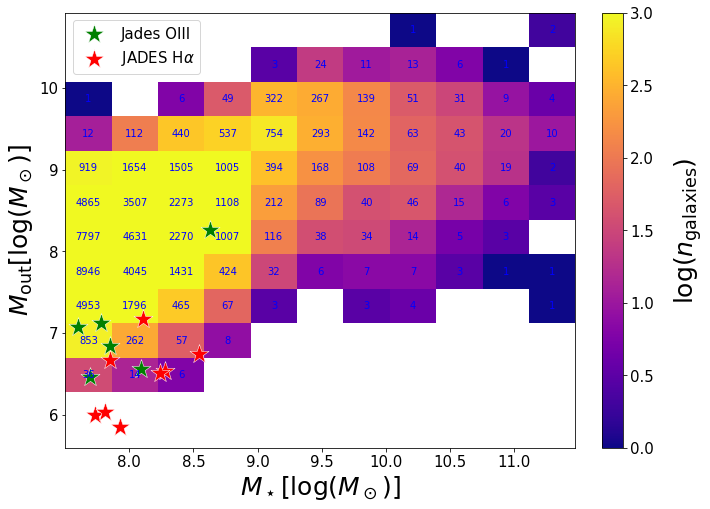

In [ ]:
prop_prop_histogram(
    df[df.M_out_aperture>0],
    prop_x='M_star_log',
    prop_y='M_out_log',
    color_prop="M_out_aperture_log",
    statistic="count",
    em_weighted=False,
    log_x=False,
    log_y=False,
    bins_x=12,
    bins_y=12,
    color_log=False,
    contour=True,
    for_slides=False,
)

/freya/u/ivkos/outflows/plotting.py:745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/freya/u/ivkos/outflows/plotting.py:746: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_values = df[prop_x]
/freya/u/ivkos/outflows/plotting.py:776: RuntimeWarning: divide by zero encountered in log10
  cont_centers_x = (xedges_cont[1:] + xedges_cont[:-1]) / 2


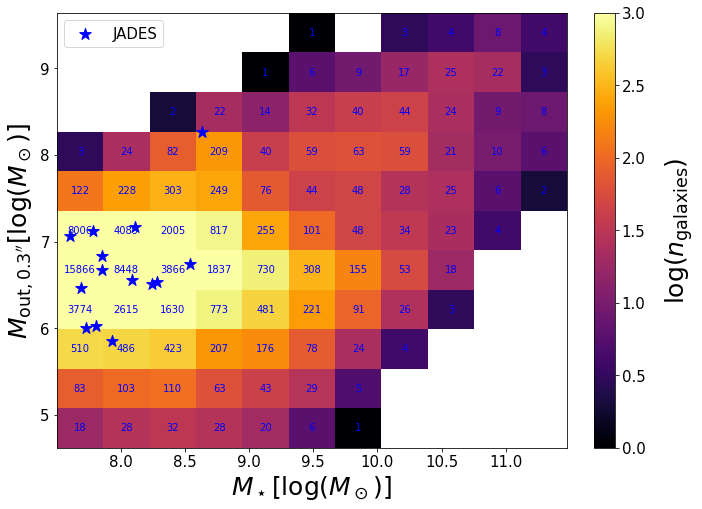

In [ ]:
prop_prop_histogram(
    df[df.M_out_aperture>0],
    prop_x='M_star_log',
    prop_y='M_out_aperture_log_03',
    color_prop="M_out_aperture_log_03",
    statistic="count",
    em_weighted=False,
    log_x=False,
    log_y=False,
    bins_x=12,
    bins_y=12,
    color_log=False,
    contour=True,
    for_slides=False,
)

In [ ]:
prop_prop_histogram(
    df[df.M_out_aperture>0],
    prop_x='M_star_log',
    prop_y='M_out_log',
    color_prop="M_out_aperture_log",
    statistic="count",
    em_weighted=False,
    log_x=False,
    log_y=False,
    bins_x=12,
    bins_y=12,
    color_log=False,
    contour=True,
    for_slides=False,
)

In [ ]:
filter_low = (df.M_star_log>8.5)&(np.log10(df.M_out)<7.5)&(df.M_star_log<8.6)
filter_high = (df.M_star_log>8.5)&(np.log10(df.M_out)>8)&(df.M_star_log<8.6)


In [ ]:
df['SFR_log'] = np.log10(df.Galaxy_SFR)
df['M_out/M_star'] = df["M_out"]/df['Galaxy_M_star']
df['M_out/M_gas'] = df["M_out"]/df['Galaxy_M_gas']
df['M_gas_log'] = np.log10(df.Galaxy_M_gas*1e10/0.6774)
df['M_star_log'] = np.log10(df.Galaxy_M_star*1e10/0.6774)


/u/ivkos/conda-envs/outflows/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/ivkos/conda-envs/outflows/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df[['Halo_id', 'snap']]

,Halo_id,snap
13661,0,13
13662,1,13
13663,2,13
13664,3,13
13665,4,13
...,...,...
145861,18150,25
146150,19203,25
146345,20138,25
146472,20937,25


In [ ]:
gal = GalaxyProjections(
                        df=self.df,
                        halo_id=halo_id,
                        snap=snap,
                        projection_angle_theta=theta,
                        projection_angle_phi=phi,
                        aperture_size=self.aperture_size,
                        backend=backend,
                    )

In [ ]:
df['W80_outflow_0_0_aperture']

13661     1378.039075
13662      585.543225
13663      279.365838
13664      271.836652
13665      291.384219
             ...     
145861      61.263293
146150      67.491864
146345            NaN
146472      92.145369
147076            NaN
Name: W80_outflow_0_0_aperture, Length: 60876, dtype: float64

In [ ]:
df['W80_outflow_0_0']

13661     1378.039075
13662      585.543225
13663      279.365838
13664      271.836652
13665      291.384219
             ...     
145861      61.263293
146150      67.491864
146345            NaN
146472      92.145369
147076            NaN
Name: W80_outflow_0_0, Length: 60876, dtype: float64

W80_outflow_0_0_aperture
W80_outflow_0_30_aperture
W80_outflow_0_60_aperture
W80_outflow_0_90_aperture


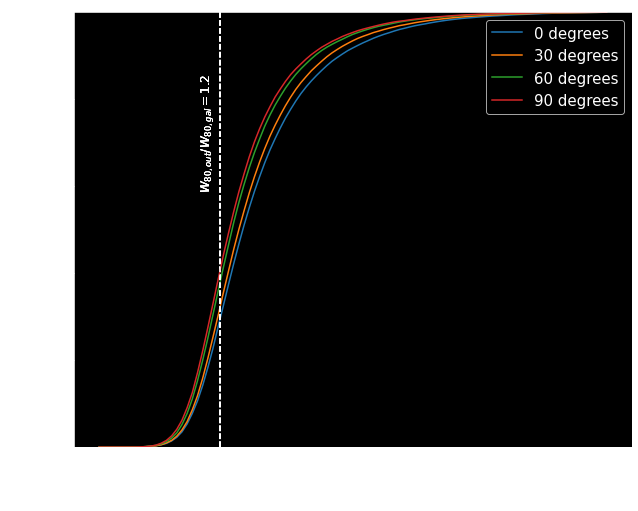

In [ ]:
plot_W80_evolution(df, theta_angles=[0, 30, 60,90], phi_angles=[0], bins=100, cumulative=True, for_slides=True, aperture=True)

In [ ]:
import os
sfr_path = '/virgotng/universe/IllustrisTNG/L35n2160TNG/postprocessing/StarFormationRates'
snap_path = 'Subhalo_SFRs_016.hdf5'
load_path = os.path.join(sfr_path, snap_path)

In [ ]:
import h5py

In [ ]:
with h5py.File(load_path, 'r') as hdf_file:
    for key in hdf_file.keys():
        print(key)

    print(hdf_file['Subhalo']['SFR_MsunPerYrs_in_all_10Myrs'][100000])

Header
Subhalo
0.0
